# QuSpin log — what the raw data is and what we do to it

The file is `data/QuSpin/T2M0-00N6_Data2.txt`, a raw serial log from a QTFM
magnetometer flown on a quadcopter. This notebook goes from the raw text to
usable arrays, showing each step.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import matplotlib.pyplot as plt

from quspin import read_log
from quspin.parse import DEFAULT_LOG

## 1. What we were given

No header, no columns, no separators. The sensor writes one line per reading
down a serial cable and the logger saves them as they arrive.

In [2]:
lines = DEFAULT_LOG.read_text(errors='replace').splitlines()

print(len(lines), 'lines,', DEFAULT_LOG.stat().st_size / 1e6, 'MB')
print()
for line in lines[:8]:
    print(line)

325091 lines, 17.619603 MB

223637639!53098.490_@066>222476s114a17.09b-47.85c-1025.88
223641640!53096.770_@067>222480s113i-0.37j-0.06k-0.61
223645642+Done
223649638#Auto Start Active
223653637!53098.847_@068>222484s114x-14.25y14.70z-23.85
0!53099.144_@069>222488s113t53.29
223657641!53097.758_@070>222492s113a17.09b-47.85c-1025.88
223661637!53097.495_@071>222496s113i-0.37j-0.06k-0.61


## 2. Reading one line

The fields are separated by punctuation rather than commas:

```
223637639!53098.490_@066>222476s114a17.09b-47.85c-1025.88
    |         |        |     |    |   |
    |         |        |     |    |   +-- one auxiliary reading
    |         |        |     |    +------ signal level
    |         |        |     +----------- a second clock, milliseconds
    |         |        +----------------- sample counter, 0-249
    |         +-------------------------- TOTAL FIELD in nT
    +------------------------------------ timestamp in microseconds
```

In [3]:
import re

pattern = re.compile(r'^(\d+)!([\d.]+)_@(\d+)>(\d+)s(\d+)(.*)$')
m = pattern.match(lines[0])

print('timestamp  ', m.group(1), 'microseconds')
print('field      ', m.group(2), 'nT')
print('counter    ', m.group(3))
print('clock 2    ', m.group(4), 'ms')
print('signal     ', m.group(5))
print('aux        ', m.group(6))

timestamp   223637639 microseconds
field       53098.490 nT
counter     066
clock 2     222476 ms
signal      114
aux         a17.09b-47.85c-1025.88


The counter runs 0 to 249 and then wraps. That is how we know the rate is
250 Hz — it resets once per second.

In [4]:
counters = [int(pattern.match(l).group(3)) for l in lines[:600] if pattern.match(l)]

print('counter range :', min(counters), 'to', max(counters))
print('first 20      :', counters[:20])

counter range : 0 to 249
first 20      : [66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85]


## 3. The interleaved channels

Only one auxiliary reading fits per line, so the sensor cycles through four
of them in turn. Each one therefore arrives at a quarter of the sample rate.

In [5]:
for line in lines[4:12]:
    m = pattern.match(line)
    if m:
        print(f'{m.group(2):>10} nT   aux: {m.group(6)}')

 53098.847 nT   aux: x-14.25y14.70z-23.85
 53099.144 nT   aux: t53.29
 53097.758 nT   aux: a17.09b-47.85c-1025.88
 53097.495 nT   aux: i-0.37j-0.06k-0.61
 53098.104 nT   aux: x-14.25y14.70z-23.85
 53100.216 nT   aux: t53.29
 53099.460 nT   aux: a17.09b-47.36c-1026.37
 53097.258 nT   aux: i-0.49j0.00k-0.67


Decoded, the four are:

| tag | channel | units |
|---|---|---|
| `a b c` | accelerometer | milli-g (1000 = one g) |
| `i j k` | gyroscope | degrees per second |
| `x y z` | 3-axis magnetometer | microtesla |
| `t` | sensor temperature | degrees C |

## 4. The position lines

Mixed into the same stream, once a second, is the GPS. Different format entirely.

In [6]:
for line in lines:
    if 'GNSSFIX' in line:
        print(line)
        break

print()
print('fields: timestamp, marker, lat x 1e7, lon x 1e7, Y, M, D, h, m, s, altitude, ?')
print()
print('so latitude ', 440776320 / 1e7)
print('   longitude', -798143744 / 1e7)

224447691,GNSSFIX,440766784,-798098624,2026,06,08,19,40,57,236,1

fields: timestamp, marker, lat x 1e7, lon x 1e7, Y, M, D, h, m, s, altitude, ?

so latitude  44.077632
   longitude -79.8143744


## 5. What the parser changes

**Changed**

- timestamps from microseconds-since-power-on to seconds from the first sample
- 4 lines print their timestamp as `0`. Their field reading is fine, so the
  timestamp is rebuilt from the neighbours rather than binning the sample
- latitude and longitude divided by 10⁷ to give degrees
- the four aux channels separated out, each keeping its own timestamps

**Not changed**

- no filtering, no smoothing, no gap filling, no outlier removal
- field values exactly as recorded

In [7]:
log = read_log()
log.summary()

T2M0-00N6_Data2.txt

magnetometer
  samples        323,790
  duration       1295.2 s  (21.6 min)
  rate           250.0 Hz
  total field    52,985.9 to 53,253.9 nT
  mean / std     53,139.4 / 19.5 nT
  signal level   106 to 127
  repaired       4 missing timestamps

auxiliary channels
  accelerometer  80,948 samples (62.5 Hz)   -2679.20 to    616.21 mg
  gyroscope     80,948 samples (62.5 Hz)    -188.72 to    184.70 deg/s
  mag vector    80,947 samples (62.5 Hz)     -42.60 to     37.05 uT
  temperature   80,947 samples (62.5 Hz)      53.09 to     80.51 C

position
  fixes          1,295  (1.00 Hz)
  utc            2026-06-08 19:40:57  to  2026-06-08 20:02:31
  latitude       44.075478 to 44.078419
  longitude      -79.818534 to -79.809786
  area covered   699 m east-west  x  327 m north-south
  track length   6.97 km
  altitude       232 to 281 m above the ellipsoid
  speed          5.1 m/s median, 14.3 max

status lines
  223645642+Done
  223649638#Auto Start Active
  284741712+Done
 

## 6. Cutting off the ground time

The sensor was running before takeoff and after landing. Those minutes contain
startup transients that are not measurements of anything. `airborne()` finds
takeoff from the GPS altitude and trims both ends.

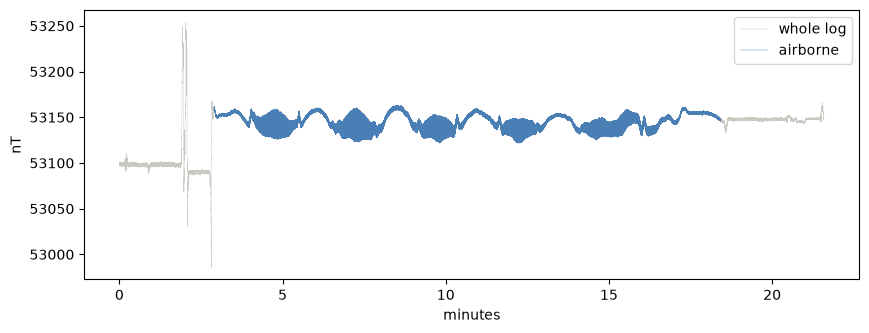

In [8]:
flight = log.airborne()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(log.time_s / 60, log.field_nt, linewidth=0.3, color='#c9c9c2', label='whole log')
ax.plot(flight.time_s / 60, flight.field_nt, linewidth=0.3, color='#4a7fb5', label='airborne')
ax.set_xlabel('minutes')
ax.set_ylabel('nT')
ax.legend()
plt.show()

## 7. The noise, and where it comes from

The flight trace looks fuzzy. Splitting it into a slow part and a fast part
shows about 5 nT of noise sitting on top of the signal.

In [9]:
from scipy import signal as sp

smooth = flight.smoothed_field(cutoff_hz=1.0)
noise = flight.field_nt - smooth

print('signal (slow) std', round(smooth.std(), 2), 'nT')
print('noise  (fast) std', round(noise.std(), 2), 'nT')

signal (slow) std 7.28 nT
noise  (fast) std 4.85 nT


Asking which frequencies the noise sits at gives the answer immediately.

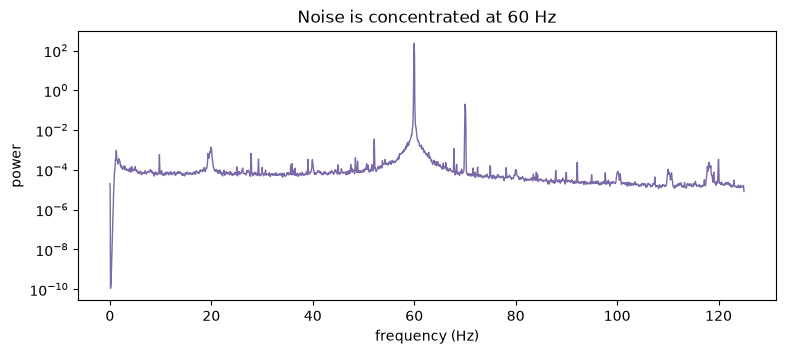

peak at 60.0 Hz


In [10]:
freq, power = sp.welch(noise, fs=flight.rate_hz, nperseg=4096)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.semilogy(freq, power, linewidth=1, color='#7a6ba8')
ax.set_xlabel('frequency (Hz)')
ax.set_ylabel('power')
ax.set_title('Noise is concentrated at 60 Hz')
plt.show()

print('peak at', round(freq[np.argmax(power)], 1), 'Hz')

60 Hz is North American mains — power lines near the survey field, picked up
by the sensor. It is environmental rather than the aircraft: it does not
correlate with heading or with how hard the drone is turning.

Geology cannot change faster than the drone flies over it, so everything real
is well below 1 Hz. Low-pass filtering removes the interference and keeps the
signal.

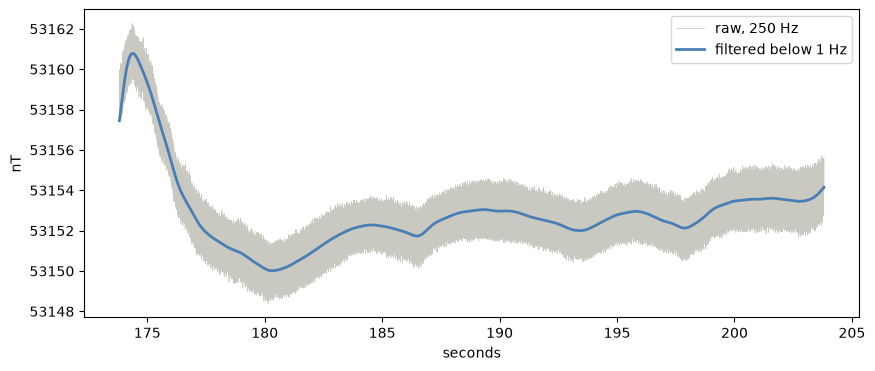

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
window = slice(0, 250 * 30)   # 30 seconds
ax.plot(flight.time_s[window], flight.field_nt[window],
        linewidth=0.5, color='#c9c9c2', label='raw, 250 Hz')
ax.plot(flight.time_s[window], smooth[window],
        linewidth=2, color='#4a7fb5', label='filtered below 1 Hz')
ax.set_xlabel('seconds')
ax.set_ylabel('nT')
ax.legend()
plt.show()

## 8. Putting position and field together

GPS arrives at 1 Hz and the magnetometer at 250 Hz, so position is interpolated
between fixes. At 6 m/s the drone covers 6 m between fixes — treat these
positions as good to a few metres, not centimetres.

In [12]:
lat, lon, alt = flight.position_at(flight.time_s)

print('one position per magnetic sample:', lat.shape, flight.field_nt.shape)
print('first:', round(lat[0], 6), round(lon[0], 6), round(alt[0], 1), 'm')

one position per magnetic sample: (232748,) (232748,)
first: 44.076646 -79.809862 244.0 m


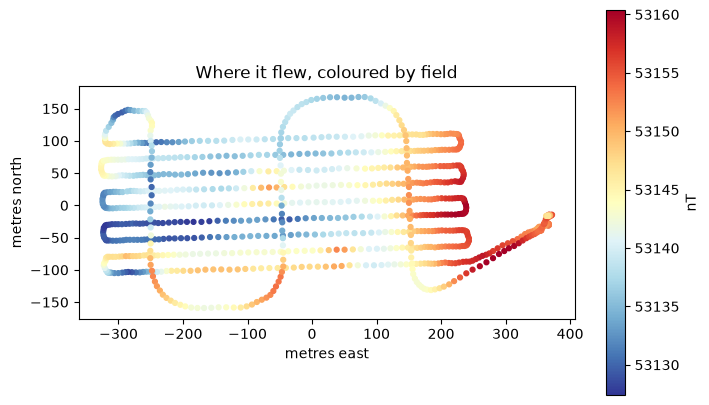

In [13]:
east, north = flight.fixes.local_xy()
field_at_fix = flight.field_at_fixes()

fig, ax = plt.subplots(figsize=(8, 5))
dots = ax.scatter(east, north, c=field_at_fix, cmap='RdYlBu_r', s=12)
ax.set_aspect('equal')
ax.set_xlabel('metres east')
ax.set_ylabel('metres north')
ax.set_title('Where it flew, coloured by field')
fig.colorbar(dots, label='nT')
plt.show()

## 9. Is the data good enough to navigate with?

The lawnmower pattern passes near the same ground more than once. Binning into
25 m cells, the spread *within* a cell is measurement error and the spread
*between* cells is real geology. The ratio is what matters.

In [14]:
import sys
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'scripts'))
from inspect_quspin import repeatability

repeatability(flight)


repeatability, in 25 m cells
  cells visited more than once   238 of 250
  spread within a cell (error)   0.7 nT median, 2.1 nT at the 90th percentile
  spread between cells (signal)  7.6 nT
  signal to error                12 : 1


About 12:1. The sensor resolves real ground structure well above its own
noise floor, which is the result you want.

The limitation is not the sensor, it is the area: 700 x 330 m with 33 nT of
total variation is too small a patch to fix a position against a map.